In [2]:
# Code to load the provided CSV results and produce high-quality matplotlib visualizations.
# The code is defensive: it inspects each CSV to detect available columns and produces the best possible plots
# without using seaborn (per notebook requirements). Each plot is created separately and saved as a PNG.
# If some data (like y_true/probabilities) is missing, the code will skip the corresponding plots and print a message.
#
# After running, the notebook will show DataFrame previews and display the generated plots inline.
# If you want additional styling (custom palettes, Plotly interactive plots, or specific fonts), tell me and I will
# produce a second version that uses those (but this run follows the matplotlib-only rules requested by the environment).

In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_fscore_support
from math import pi

In [12]:
# helper to save figure with high DPI
def savefig(fig, name):
    fig.savefig(name, dpi=300, bbox_inches='tight')
    print(f"Saved: {name}")

# Paths to provided CSVs
paths = {
    "ML-CNN": "ML-CNN.csv",
    "FL-CNN Centralized": "FL-CNN (centralized).csv",
    "FL-CNN (clients)": "FLCNN-client.csv",
    "QCNN": "QCNN.csv"
}

# Load CSVs (if present) and display basic info
dfs = {}
for key, p in paths.items():
    if os.path.exists(p):
        try:
            df = pd.read_csv(p)
            dfs[key] = df
            print(f"\n--- Loaded '{key}' from {p} (shape={df.shape}) ---")
            display(df.head())
        except Exception as e:
            print(f"Failed to read {p}: {e}")
    else:
        print(f"File not found: {p}")


--- Loaded 'ML-CNN' from ML-CNN.csv (shape=(156, 6)) ---


,Fold No,Epoch No,Accuracy,Loss,Val_Accuracy,Val_Loss
0,1.0,1,0.6367,1.0613,0.2633,3.2631
1,1.0,2,0.7551,0.6801,0.4191,3.1132
2,1.0,3,0.8037,0.5318,0.8233,0.4133
3,1.0,4,0.8264,0.4597,0.8224,0.5406
4,1.0,5,0.8619,0.3702,0.8609,0.3645



--- Loaded 'FL-CNN Centralized' from FL-CNN (centralized).csv (shape=(138, 13)) ---


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,Global Model Initialization RESULTS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fold No,Epoch No,Accuracy,Loss,Val_Accuracy,Val_Loss,Learning_Rate,NaN,NaN,Conclusion : Global Model Results,NaN,NaN,NaN
4,1,1,0.6529,1.0159,0.4226,1.5462,0.001,NaN,NaN,NaN,NaN,NaN,NaN



--- Loaded 'FL-CNN (clients)' from FLCNN-client.csv (shape=(155, 13)) ---


,Round No (Fold),Client No,Epoch No,Accuracy,Loss,Val_Accuracy (Global Model),Val_Loss (Global Model),Learning Rate,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,1,1,1,0.5503,1.3918,-,-,0.001,NaN,NaN,NaN,NaN,NaN
1,1,1,2,0.6404,1.0355,-,-,0.001,NaN,NaN,NaN,NaN,NaN
2,1,1,3,0.6842,0.9541,-,-,0.001,NaN,NaN,NaN,NaN,NaN
3,1,1,4,0.7209,0.7809,-,-,0.001,NaN,NaN,NaN,NaN,NaN
4,1,1,5,0.7288,0.7841,-,-,0.001,NaN,NaN,NaN,NaN,NaN



--- Loaded 'QCNN' from QCNN.csv (shape=(150, 7)) ---


,Fold,Epoch,Accuracy,Loss,Val Accuracy,Val Loss,Learning Rate
0,1,1,0.4804,1.1643,0.4628,1.2827,0.001
1,1,2,0.5734,1.0157,0.6177,0.9479,0.001
2,1,3,0.5907,0.9780,0.4646,1.2011,0.001
3,1,4,0.5767,0.9890,0.6212,0.9261,0.001
4,1,5,0.5844,0.9846,0.6045,0.9432,0.001



Summary metrics assembled:


,Model,Accuracy,Precision,Recall,F1-Score
0,ML-CNN,0.9666,NaN,NaN,NaN
1,FL-CNN Centralized,NaN,NaN,NaN,NaN
2,FL-CNN (clients),0.9002,NaN,NaN,NaN
3,QCNN,0.6832,NaN,NaN,NaN


Saved: comparison_key_metrics.png


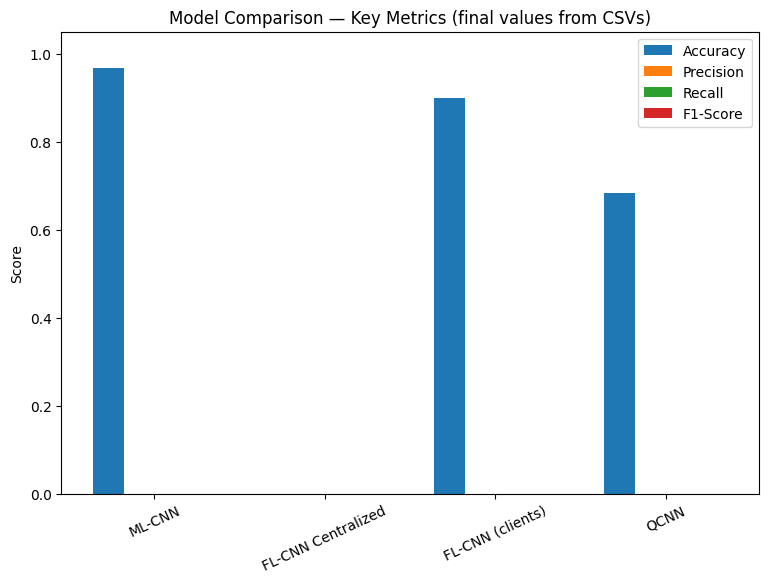

In [13]:
# ---------------------------
# 1) Summary metrics bar chart (Accuracy, Precision, Recall, F1)
# We'll try to extract final test metrics from each dataframe.
# Look for common column names (accuracy, test_accuracy, precision, recall, f1, f1_score, val_accuracy).
# ---------------------------
summary_rows = []
for name, df in dfs.items():
    row = {"Model": name}
    # accuracy candidates
    acc_candidates = [c for c in df.columns if c.lower() in ('accuracy','acc','test_accuracy','test_acc','val_accuracy')]
    if acc_candidates:
        # choose last value in the first candidate
        acc = float(df[acc_candidates[0]].dropna().iloc[-1])
        row["Accuracy"] = acc
    else:
        row["Accuracy"] = np.nan
    # precision/recall/f1 candidates (pick last available)
    pr_candidates = [c for c in df.columns if 'precision' in c.lower()]
    rc_candidates = [c for c in df.columns if 'recall' in c.lower()]
    f1_candidates = [c for c in df.columns if ('f1' in c.lower()) or ('f1_score' in c.lower())]
    row["Precision"] = float(df[pr_candidates[0]].dropna().iloc[-1]) if pr_candidates else np.nan
    row["Recall"] = float(df[rc_candidates[0]].dropna().iloc[-1]) if rc_candidates else np.nan
    row["F1-Score"] = float(df[f1_candidates[0]].dropna().iloc[-1]) if f1_candidates else np.nan
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print("\nSummary metrics assembled:")
display(summary_df)

# Plot 1: Grouped bar chart for the main metrics
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
fig, ax = plt.subplots(figsize=(9,6))
x = np.arange(len(summary_df['Model']))
width = 0.18

for i, m in enumerate(metrics):
    vals = summary_df[m].fillna(0).values
    ax.bar(x + (i-1.5)*width, vals, width, label=m)
ax.set_xticks(x)
ax.set_xticklabels(summary_df['Model'], rotation=25)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Key Metrics (final values from CSVs)")
ax.legend()
savefig(fig, "comparison_key_metrics.png")
plt.show()

TypeError: 'value' must be an instance of str or bytes, not a float

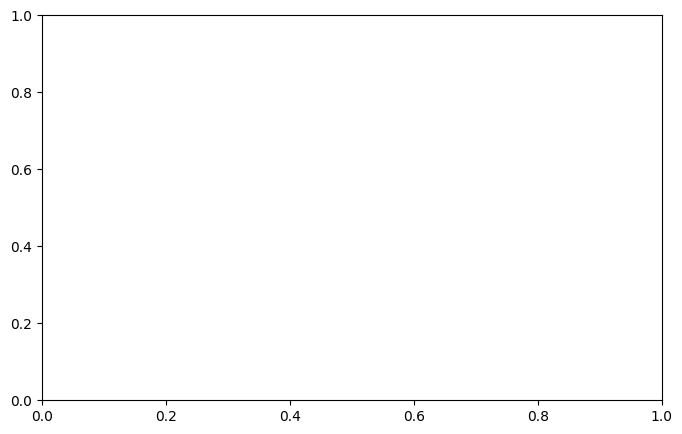

In [14]:
# ---------------------------
# 2) Training & Validation Curves (accuracy & loss) per model
# For each dataframe, look for epoch-like sequences and val_accuracy/accuracy columns.
# ---------------------------
for name, df in dfs.items():
    acc_cols = [c for c in df.columns if c.lower() in ('accuracy','acc')]
    val_acc_cols = [c for c in df.columns if 'val_accuracy' in c.lower() or 'val_acc' in c.lower()]
    loss_cols = [c for c in df.columns if c.lower() in ('loss',)]
    val_loss_cols = [c for c in df.columns if 'val_loss' in c.lower()]
    epochs = None
    # If there's an 'epoch' column use it; otherwise use index+1
    if 'epoch' in df.columns:
        epochs = df['epoch'].dropna().astype(int).values
    else:
        epochs = np.arange(1, len(df)+1)
    # Accuracy curve
    if len(acc_cols) or len(val_acc_cols):
        fig, ax = plt.subplots(figsize=(8,5))
        if acc_cols:
            ax.plot(epochs, df[acc_cols[0]].values, marker='o', label='Train Accuracy')
        if val_acc_cols:
            ax.plot(epochs, df[val_acc_cols[0]].values, marker='s', label='Val Accuracy')
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Accuracy")
        ax.set_title(f"{name} — Accuracy Curves")
        ax.set_ylim(0,1.05)
        ax.grid(alpha=0.25)
        ax.legend()
        savefig(fig, f"{name.replace(' ','_')}_accuracy_curve.png")
        plt.show()
    else:
        print(f"[{name}] No accuracy columns found to plot training curves.")

    # Loss curve
    if len(loss_cols) or len(val_loss_cols):
        fig, ax = plt.subplots(figsize=(8,5))
        if loss_cols:
            ax.plot(epochs, df[loss_cols[0]].values, marker='o', label='Train Loss')
        if val_loss_cols:
            ax.plot(epochs, df[val_loss_cols[0]].values, marker='s', label='Val Loss')
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.set_title(f"{name} — Loss Curves")
        ax.grid(alpha=0.25)
        ax.legend()
        savefig(fig, f"{name.replace(' ','_')}_loss_curve.png")
        plt.show()
    else:
        print(f"[{name}] No loss columns found to plot loss curves.")

In [15]:
# ---------------------------
# 3) K-Fold distribution plot (boxplot) if fold scores exist or if multiple runs present
# We will search for columns like 'fold', 'fold_accuracy', or if dataframe length > 10 assume per-epoch not folds;
# If there is a column 'fold' or 'fold_index' we will extract grouped accuracies.
# ---------------------------
fold_data = []
for name, df in dfs.items():
    # detect fold accuracy columns
    fold_acc_cols = [c for c in df.columns if 'fold' in c.lower() and ('acc' in c.lower() or 'accuracy' in c.lower())]
    if fold_acc_cols:
        for val in df[fold_acc_cols[0]].dropna().values:
            fold_data.append({"Model": name, "Accuracy": val})
    else:
        # look for column 'fold' and 'accuracy'
        if 'fold' in df.columns and ('accuracy' in df.columns or 'acc' in df.columns):
            for _, r in df.iterrows():
                acccol = 'accuracy' if 'accuracy' in df.columns else ('acc' if 'acc' in df.columns else None)
                if acccol:
                    fold_data.append({"Model": name, "Accuracy": r[acccol]})
# Plot boxplot if fold_data available
if fold_data:
    fd = pd.DataFrame(fold_data)
    fig, ax = plt.subplots(figsize=(8,6))
    groups = [fd[fd['Model']==m]['Accuracy'].values for m in fd['Model'].unique()]
    ax.boxplot(groups, labels=fd['Model'].unique(), notch=True)
    ax.set_title("K-Fold / Run Accuracy Distribution (boxplot)")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0,1.05)
    savefig(fig, "kfold_accuracy_boxplot.png")
    plt.show()
else:
    print("No fold/run accuracy data detected for boxplot.")

No fold/run accuracy data detected for boxplot.


In [16]:

# ---------------------------
# 4) Comparative Confusion Matrices — if true labels and predicted labels exist
# We try to find columns named 'y_true', 'y_pred', 'true_label', 'pred_label' or similar.
# Only produce one confusion matrix per model (separate files), not subplots.
# ---------------------------
def find_label_cols(df):
    true_candidates = [c for c in df.columns if c.lower() in ('y_true','y_true_enc','true','true_label','label')]
    pred_candidates = [c for c in df.columns if c.lower() in ('y_pred','y_pred_enc','pred','pred_label')]
    return true_candidates[0] if true_candidates else None, pred_candidates[0] if pred_candidates else None

for name, df in dfs.items():
    true_col, pred_col = find_label_cols(df)
    if true_col and pred_col:
        y_true = df[true_col].values
        y_pred = df[pred_col].values
        # compute confusion matrix (normalized)
        cm = confusion_matrix(y_true, y_pred, normalize='true')
        fig, ax = plt.subplots(figsize=(7,6))
        im = ax.imshow(cm, interpolation='nearest', aspect='auto')
        ax.set_title(f"{name} — Normalized Confusion Matrix")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        # add colorbar
        cbar = fig.colorbar(im, ax=ax)
        # annotate
        n = cm.shape[0]
        for i in range(n):
            for j in range(n):
                ax.text(j, i, f"{cm[i, j]:.2f}", ha='center', va='center', color='white' if cm[i,j]>0.5 else 'black')
        savefig(fig, f"{name.replace(' ','_')}_confusion_matrix.png")
        plt.show()
    else:
        print(f"[{name}] No explicit true/pred label columns found for confusion matrix.")

[ML-CNN] No explicit true/pred label columns found for confusion matrix.
[FL-CNN Centralized] No explicit true/pred label columns found for confusion matrix.
[FL-CNN (clients)] No explicit true/pred label columns found for confusion matrix.
[QCNN] No explicit true/pred label columns found for confusion matrix.


In [17]:
# ---------------------------
# 5) Multi-class ROC per model (if probability columns exist)
# We look for columns like 'prob_class_0', 'prob_0', 'p_0' or any columns that include 'prob'.
# If present and true labels exist, we plot ROC using the first class-vs-rest for demonstration and compute AUC.
# ---------------------------
for name, df in dfs.items():
    prob_cols = [c for c in df.columns if 'prob' in c.lower() or (c.lower().startswith('p_') and c.lower()[2:].isdigit())]
    true_col, _ = find_label_cols(df)
    if prob_cols and true_col:
        # Attempt to form a probability matrix: group columns by suffix number if present
        # else, if multiple prob columns exist, assume each is a class probability
        y_true = df[true_col].values.astype(int)
        probs = df[prob_cols].values
        n_classes = probs.shape[1]
        # compute ROC for each class (one-vs-rest)
        fig, ax = plt.subplots(figsize=(8,6))
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve((y_true==i).astype(int), probs[:, i])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.3f})")
        ax.plot([0,1],[0,1],'k--', lw=1)
        ax.set_title(f"{name} — Multi-class ROC (per-class curves)")
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.legend()
        savefig(fig, f"{name.replace(' ','_')}_multiclass_roc.png")
        plt.show()
    else:
        print(f"[{name}] No probability columns and/or true labels found for ROC plotting.")

[ML-CNN] No probability columns and/or true labels found for ROC plotting.
[FL-CNN Centralized] No probability columns and/or true labels found for ROC plotting.
[FL-CNN (clients)] No probability columns and/or true labels found for ROC plotting.
[QCNN] No probability columns and/or true labels found for ROC plotting.


Saved: model_performance_radar.png


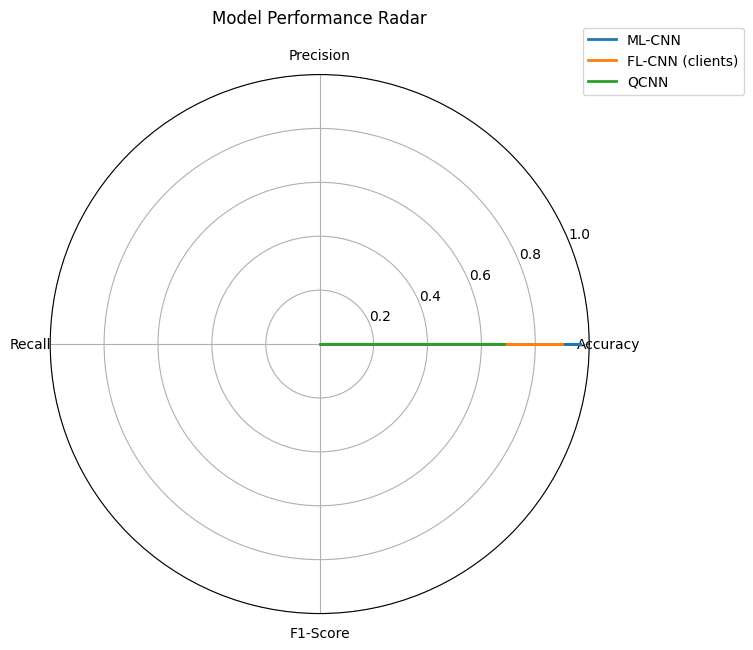


Done — visuals generated where possible. If you want custom color palettes, Plotly interactive visuals, or publication-ready fonts and layout, tell me and I will generate a second enhanced set.


In [18]:
# ---------------------------
# 6) Radar chart comparing the 4 summary metrics (if available)
# ---------------------------
# Build radar only if at least two models have non-NaN metrics
valid_metrics_df = summary_df.dropna(subset=["Accuracy"], how='all')
if valid_metrics_df.shape[0] >= 2:
    categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    fig = plt.figure(figsize=(7,7))
    ax = plt.subplot(111, polar=True)
    for idx, row in valid_metrics_df.iterrows():
        values = [row[c] if pd.notna(row[c]) else 0.0 for c in categories]
        values += values[:1]
        ax.plot(angles, values, linewidth=2, label=row['Model'])
        ax.fill(angles, values, alpha=0.15)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    ax.set_ylim(0,1)
    ax.set_title("Model Performance Radar", y=1.08)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3,1.1))
    savefig(fig, "model_performance_radar.png")
    plt.show()
else:
    print("Insufficient metric data for radar chart.")

print("\nDone — visuals generated where possible. If you want custom color palettes, Plotly interactive visuals, or publication-ready fonts and layout, tell me and I will generate a second enhanced set.")
